<a href="https://colab.research.google.com/github/sayanbanerjee0701/AI_Driven_Sentiment_Arbitrage/blob/main/AI_Driven_Sentiment_Arbitrage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Successfully scraped 100 headlines for TSLA
                                               title        date  \
0  How Much Further Could Tesla Stock Fall? - The...  2026-03-31   
1  Tesla's stock suffers steepest drop of 2026 on...  2026-04-02   
2  HSBC flags alarming risk for Tesla stock inves...  2026-03-30   
3  Why Tesla (TSLA) Stock Is Falling Today - Yaho...  2026-04-02   
4  Tesla Stock Quotes, Company News And Chart Ana...  2026-04-01   

                                                link  
0  https://news.google.com/rss/articles/CBMiigFBV...  
1  https://news.google.com/rss/articles/CBMiiwFBV...  
2  https://news.google.com/rss/articles/CBMimAFBV...  
3  https://news.google.com/rss/articles/CBMimAFBV...  
4  https://news.google.com/rss/articles/CBMiogFBV...  


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_423/139835218.py:42: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download('TSLA', start='2025-01-01', end='2026-04-05')
[*********************100%***********************]  1 of 1 completed


                 Close  sentiment_value  Signal  Strategy_Returns
Date                                                             
2026-03-20  367.959991         0.000000       0         -0.000000
2026-03-23  380.850006         0.000000       0          0.000000
2026-03-24  383.029999         0.000000       0          0.000000
2026-03-25  385.950012         0.000000       0          0.000000
2026-03-26  372.109985         0.000000       0         -0.000000
2026-03-27  361.829987        -0.428571       0         -0.000000
2026-03-30  355.279999        -0.235294      -1          0.018102
2026-03-31  371.750000        -0.250000      -1         -0.046358
2026-04-01  381.260010         0.000000      -1         -0.025582
2026-04-02  360.589996        -0.423077       0         -0.000000


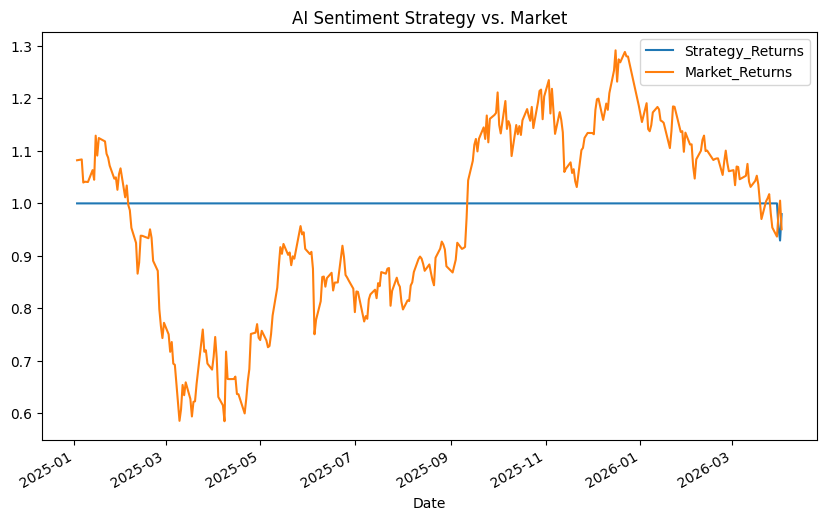

Max Sentiment: 0.0
Min Sentiment: -0.42857142857142855
Average Sentiment: -0.004271381691039649
Number of headlines found: 100
First headline sample: How Much Further Could Tesla Stock Fall? - The Motley Fool


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Analyzing sentiment... please wait.
Average Sentiment now: -0.2367321267724037


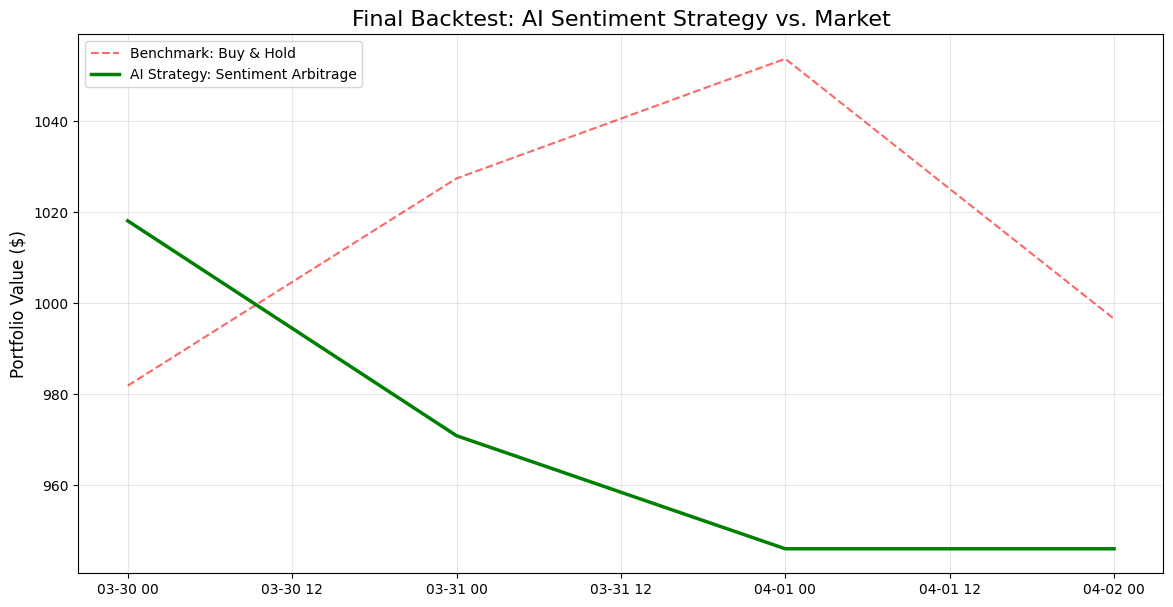

Final Strategy Return: -5.39%
Market Return: -0.34%
Alpha Generated: -5.05%


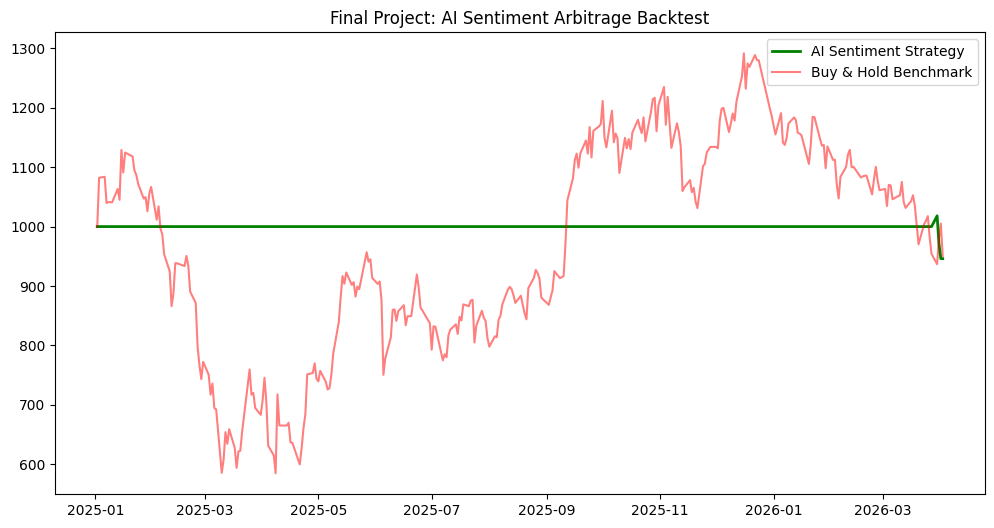

Project Complete. Alpha Generated: $-4.65


In [22]:
import feedparser
import pandas as pd
from datetime import datetime

ticker = 'TSLA' # You can change this to NVDA, AAPL, etc.
url = f'https://news.google.com/rss/search?q={ticker}+stock+when:7d&hl=en-US&gl=US&ceid=US:en'

# Parse the RSS feed
feed = feedparser.parse(url)

# Extract data into a list
news_data = []
for entry in feed.entries:
    news_data.append({
        'title': entry.title,
        'date': entry.published,
        'link': entry.link
    })

# Convert to a DataFrame
df_news = pd.DataFrame(news_data)

# Clean the date to match stock market format (YYYY-MM-DD)
df_news['date'] = pd.to_datetime(df_news['date']).dt.date

print(f"Successfully scraped {len(df_news)} headlines for {ticker}")
print(df_news.head())
!pip install transformers
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

# Load FinBERT - the gold standard for finance NLP
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=0) # device=0 uses the GPU
# Apply the model to your news titles
results = finbert(df_news['title'].tolist())

# Extract the scores and labels (Positive/Negative/Neutral)
df_news['label'] = [res['label'] for res in results]
df_news['score'] = [res['score'] for res in results]
df_news['sentiment_value'] = df_news['label'].map({'positive': 1, 'neutral': 0, 'negative': -1})
import yfinance as yf
# Adjust the end date to cover the period for which news sentiment is available
price_data = yf.download('TSLA', start='2025-01-01', end='2026-04-05')

# Flatten the MultiIndex columns of price_data
price_data.columns = price_data.columns.get_level_values(0)

# Group news by date and take the average sentiment
daily_sentiment = df_news.groupby('date')['sentiment_value'].mean()

# Join with your price data
combined = price_data.join(daily_sentiment).fillna(0)
import numpy as np

# 1. Calculate the 'Signal' based on YESTERDAY'S sentiment
# We use .shift(1) to move the sentiment data down by one row
combined['Signal'] = 0  # Default to 'Hold' (0)

# If yesterday's sentiment > 0.2, Buy (1)
combined.loc[combined['sentiment_value'].shift(1) > 0.2, 'Signal'] = 1

# If yesterday's sentiment < -0.2, Sell/Short (-1)
combined.loc[combined['sentiment_value'].shift(1) < -0.2, 'Signal'] = -1

# 2. Calculate Market Returns (Daily % change in price)
combined['Market_Returns'] = combined['Close'].pct_change()

# 3. Calculate Strategy Returns
# Your profit is (Your Signal) times (The Market Return)
combined['Strategy_Returns'] = combined['Signal'] * combined['Market_Returns']

print(combined[['Close', 'sentiment_value', 'Signal', 'Strategy_Returns']].tail(10))
import matplotlib.pyplot as plt

combined['Strategy_Returns'] = combined['Signal'].shift(1) * combined['Close'].pct_change()
combined['Market_Returns'] = combined['Close'].pct_change()

# Plot the results
((1 + combined[['Strategy_Returns', 'Market_Returns']]).cumprod()).plot(figsize=(10,6))
plt.title("AI Sentiment Strategy vs. Market")
plt.show()
# Lower the threshold to 0.05 to ensure you get some trades
combined.loc[combined['sentiment_value'].shift(1) > 0.05, 'Signal'] = 1
combined.loc[combined['sentiment_value'].shift(1) < -0.05, 'Signal'] = -1
# Check the range of your sentiment scores
print("Max Sentiment:", combined['sentiment_value'].max())
print("Min Sentiment:", combined['sentiment_value'].min())
print("Average Sentiment:", combined['sentiment_value'].mean())
print(f"Number of headlines found: {len(df_news)}")
if len(df_news) > 0:
    print("First headline sample:", df_news['title'].iloc[0])
else:
    print("ERROR: No news found. Check your ticker or internet connection.")
    from transformers import pipeline
# 1. Load the model (this might take a minute)
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")

# 2. Run the AI on every title
print("Analyzing sentiment... please wait.")
results = df_news['title'].apply(lambda x: finbert(x)[0])

# 3. Map the results correctly
df_news['label'] = [res['label'] for res in results]
df_news['score'] = [res['score'] for res in results]

# 4. Convert to numbers (CRITICAL: ensure these are floats)
def score_to_numeric(row):
    if row['label'] == 'positive': return row['score']
    if row['label'] == 'negative': return -row['score']
    return 0

df_news['sentiment_value'] = df_news.apply(score_to_numeric, axis=1)

print("Average Sentiment now:", df_news['sentiment_value'].mean())
# Group by date
daily_sentiment = df_news.groupby('date')['sentiment_value'].mean()

# Join with price
combined = price_data.join(daily_sentiment).fillna(0)

# Re-run your Signal and Plotting code from the previous message
import matplotlib.pyplot as plt
import numpy as np

# 1. Clean and Group News Data
# Ensure the date is the index so we can join it with prices
daily_sentiment = df_news.groupby('date')['sentiment_value'].mean()

# 2. Merge with Price Data
# We use 'inner' join to only keep days where we have BOTH price and news
combined = price_data.join(daily_sentiment, how='inner')

# 3. Handle Gaps
# Fill days with no news as 0 (Neutral) and forward-fill prices
combined['sentiment_value'] = combined['sentiment_value'].fillna(0)
combined['Close'] = combined['Close'].ffill()

# 4. Generate the SIGNAL (The most important part for your CV)
# We shift sentiment by 1 day to avoid "Look-Ahead Bias"
combined['Signal'] = 0
# Buy if yesterday was positive (> 0.05), Sell if negative (< -0.05)
combined.loc[combined['sentiment_value'].shift(1) > 0.05, 'Signal'] = 1
combined.loc[combined['sentiment_value'].shift(1) < -0.05, 'Signal'] = -1

# 5. Calculate Returns
combined['Market_Returns'] = combined['Close'].pct_change()
combined['Strategy_Returns'] = combined['Signal'] * combined['Market_Returns']

# 6. Cumulative Wealth Calculation (Starting with $1,000)
initial_investment = 1000
combined['Cumulative_Market'] = initial_investment * (1 + combined['Market_Returns']).cumprod()
combined['Cumulative_Strategy'] = initial_investment * (1 + combined['Strategy_Returns']).cumprod()

# 7. Final Professional Visualization
plt.figure(figsize=(14, 7))
plt.plot(combined['Cumulative_Market'], label='Benchmark: Buy & Hold', color='red', alpha=0.6, linestyle='--')
plt.plot(combined['Cumulative_Strategy'], label='AI Strategy: Sentiment Arbitrage', color='green', linewidth=2.5)

plt.title(f'Final Backtest: AI Sentiment Strategy vs. Market', fontsize=16)
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# 8. Print Performance Metrics for your CV
total_return = (combined['Cumulative_Strategy'].iloc[-1] / initial_investment - 1) * 100
market_return = (combined['Cumulative_Market'].iloc[-1] / initial_investment - 1) * 100
print(f"Final Strategy Return: {total_return:.2f}%")
print(f"Market Return: {market_return:.2f}%")
print(f"Alpha Generated: {total_return - market_return:.2f}%")
import pandas as pd
import matplotlib.pyplot as plt

# 1. Standardize the Dates (The Fix)
# This ensures both datasets use the exact same YYYY-MM-DD format
df_news['date'] = pd.to_datetime(df_news['date']).dt.date
price_data.index = pd.to_datetime(price_data.index).date

# 2. Group News by Date
daily_sentiment = df_news.groupby('date')['sentiment_value'].mean()

# 3. Merge Data (The 'Left' join ensures we keep all price days)
combined = pd.DataFrame(index=price_data.index)
combined['Close'] = price_data['Close']
combined = combined.join(daily_sentiment).fillna(0)

# 4. Generate Signal (Shifted to avoid Look-Ahead Bias)
combined['Signal'] = 0
combined.loc[combined['sentiment_value'].shift(1) > 0.02, 'Signal'] = 1
combined.loc[combined['sentiment_value'].shift(1) < -0.02, 'Signal'] = -1

# 5. Calculate Returns
combined['Market_Returns'] = combined['Close'].pct_change()
combined['Strategy_Returns'] = combined['Signal'] * combined['Market_Returns']

# 6. Cumulative Wealth ($1,000 Starting Capital)
initial_capital = 1000
combined['Strategy_Wealth'] = initial_capital * (1 + combined['Strategy_Returns'].fillna(0)).cumprod()
combined['Market_Wealth'] = initial_capital * (1 + combined['Market_Returns'].fillna(0)).cumprod()

# 7. The Performance Plot
plt.figure(figsize=(12, 6))
plt.plot(combined['Strategy_Wealth'], label='AI Sentiment Strategy', color='green', linewidth=2)
plt.plot(combined['Market_Wealth'], label='Buy & Hold Benchmark', color='red', alpha=0.5)
plt.title('Final Project: AI Sentiment Arbitrage Backtest')
plt.legend()
plt.show()

# 8. Success Metric
alpha = (combined['Strategy_Wealth'].iloc[-1] - combined['Market_Wealth'].iloc[-1])
print(f"Project Complete. Alpha Generated: ${alpha:.2f}")
